In [2]:
# Manipulations standard
import geopandas as gpd
import pandas as pd
# Plotting
import matplotlib.pyplot as plt
# Pour la basemap
import contextily as cx

# Acquisition des données

## En commencant par le territoire à couvrir

<Axes: >

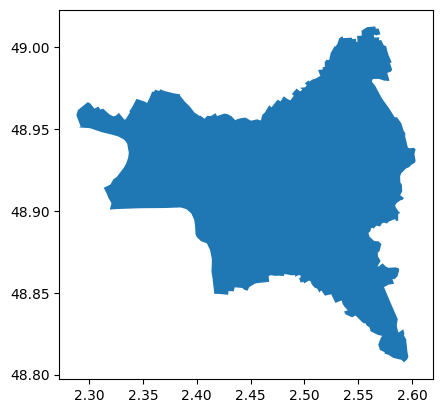

In [49]:
dpts = gpd.read_file("data/contour-des-departements.geojson").to_crs(4326)
ShapeNT = dpts[dpts.code == "93"].geometry
ShapeNT.plot()

## On load les écoles

In [24]:
# Takes 10s on my laptop
annuaire = gpd.read_file('data/fr-en-annuaire-education.geojson')
print(len(annuaire),"items")
annuaire = annuaire[annuaire.code_postal.str.startswith("93")]
print(len(annuaire),"objets dans le 93")
annuaire = annuaire.to_crs(4326)
annuaire.head(3)

69645 items
1432 objets dans le 93


,identifiant_de_l_etablissement,nom_etablissement,type_etablissement,statut_public_prive,adresse_1,adresse_2,adresse_3,code_postal,code_commune,nom_commune,...,code_type_contrat_prive,pial,etablissement_mere,type_rattachement_etablissement_mere,code_circonscription,code_zone_animation_pedagogique,libelle_zone_animation_pedagogique,code_bassin_formation,libelle_bassin_formation,geometry
5985,0930152K,Ecole élémentaire Pierre Lerenard,Ecole,Public,115 rue de l'Avenir,None,93130 NOISY LE SEC,93130,93053,Noisy-le-Sec,...,99,None,None,None,0932428J,None,None,None,None,POINT (2.45777 48.88098)
5986,0930180R,Ecole élémentaire Eugène Varlin,Ecole,Public,62 avenue Edouard Vaillant,None,93000 BOBIGNY,93000,93008,Bobigny,...,99,None,None,None,0931856M,None,None,None,None,POINT (2.46766 48.91014)
5987,0930205T,Ecole élémentaire d'application Roger Sémat,Ecole,Public,4 villa des Joncherolles,None,93200 ST DENIS,93200,93066,Saint-Denis,...,99,None,None,None,0932609F,None,None,None,None,POINT (2.35543 48.94863)


## On load la BDTOPO

In [169]:
import fiona

Vérifions quelles sont les layers de dispo dans le gpkg

In [225]:
GPKG = "data/BDTOPO/1_DONNEES_LIVRAISON_2024-12-00134/BDT_3-4_GPKG_LAMB93_D093-ED2024-12-15/BDT_3-4_GPKG_LAMB93_D093-ED2024-12-15.gpkg"
layers = fiona.listlayers(GPKG)
print(" ".join(layers))

troncon_de_route route_numerotee_ou_nommee itineraire_autre troncon_de_voie_ferree equipement_de_transport piste_d_aerodrome aerodrome point_de_repere non_communication point_du_reseau voie_ferree_nommee toponymie_transport batiment cimetiere construction_lineaire construction_ponctuelle construction_surfacique reservoir ligne_orographique pylone terrain_de_sport toponymie_bati cours_d_eau troncon_hydrographique bassin_versant_topographique plan_d_eau surface_hydrographique noeud_hydrographique detail_hydrographique toponymie_hydrographie zone_d_habitation lieu_dit_non_habite detail_orographique toponymie_lieux_nommes canalisation ligne_electrique poste_de_transformation erp zone_d_activite_ou_d_interet toponymie_services_et_activites voie_nommee parc_ou_reserve foret_publique toponymie_zones_reglementees haie zone_de_vegetation arrondissement arrondissement_municipal commune epci collectivite_territoriale departement region adresse_ban batiment_rnb_lien_bdtopo lien_adresse_vers_bdtopo

Et on les display

In [229]:
bats = gpd.read_file(GPKG, layer="batiment")# toponymie_services_et_activites
bats = bats.to_crs(4326) 

In [227]:
bats.columns

Index(['cleabs', 'nature', 'usage_1', 'usage_2', 'construction_legere',
       'etat_de_l_objet', 'date_creation', 'date_modification',
       'date_d_apparition', 'date_de_confirmation', 'sources',
       'identifiants_sources', 'methode_d_acquisition_planimetrique',
       'methode_d_acquisition_altimetrique', 'precision_planimetrique',
       'precision_altimetrique', 'nombre_de_logements', 'nombre_d_etages',
       'materiaux_des_murs', 'materiaux_de_la_toiture', 'hauteur',
       'altitude_minimale_sol', 'altitude_minimale_toit',
       'altitude_maximale_toit', 'altitude_maximale_sol',
       'origine_du_batiment', 'appariement_fichiers_fonciers',
       'identifiants_rnb', 'geometry'],
      dtype='object')

13348 items
1432 objets dans le 93
1385 items


<Axes: >

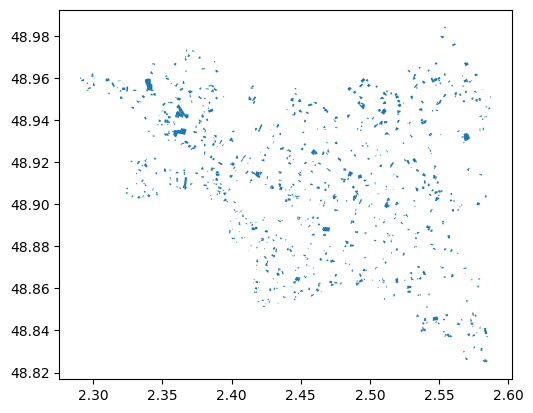

In [ ]:
# Takes 10s on my laptop
bdedu = gpd.read_file(GPKG, layer="zone_d_activite_ou_d_interet")# toponymie_services_et_activites
print(len(bdedu),"items")
# Utilisons les memes projections
bdedu = bdedu.to_crs(4326) 
# Tri sur la catégorie d'intéret
bdedu = bdedu[bdedu["categorie"] == "Science et enseignement"] 
bdedu = gpd.sjoin(bdedu, dpts[dpts.code == "93"], how='left').dropna(subset="code")
print(len(bdedu),"items dans la zone")
bdedu.plot()

In [234]:
bdedu.head()

,cleabs,categorie,nature,nature_detaillee,toponyme,statut_du_toponyme,importance,fictif,etat_de_l_objet,date_creation,...,sources,identifiants_sources,methode_d_acquisition_planimetrique,precision_planimetrique,identifiant_voie_ban,nom_commercial,geometry,index_right,code,nom
317,SURFACTI0000000244379147,Science et enseignement,Structure d'accueil pour personnes handicapées,Etablissement et service d'aide par le travail,ESAT des Muguets,Collecté,5,True,En service,2010-10-13 09:33:35.048,...,FINESS 2022,FINESS:930021340,Calculé,20.0,None,None,"MULTIPOLYGON (((2.44437 48.93429, 2.4443 48.93...",93.0,93,Seine-Saint-Denis
346,SURFACTI0000000315148811,Science et enseignement,Autre établissement d'enseignement,Centre de formation d'apprentis,Antenne du C.F.A.,Collecté,5,True,En service,2012-11-07 14:03:32.418,...,MEN 2022,MEN:0932508W,Calculé,20.0,None,None,"MULTIPOLYGON (((2.51118 48.9713, 2.51118 48.97...",93.0,93,Seine-Saint-Denis
377,SURFACTI0000000244379123,Science et enseignement,Structure d'accueil pour personnes handicapées,Etablissement et service d'aide par le travail,ESAT Apf,Collecté,5,True,En service,2010-10-13 09:32:09.389,...,FINESS 2022,FINESS:930010509,Calculé,20.0,None,None,"MULTIPOLYGON (((2.44829 48.89549, 2.44822 48.8...",93.0,93,Seine-Saint-Denis
446,SURFACTI0000000312695110,Science et enseignement,Enseignement supérieur,None,Cnfsicg,Collecté,3,True,En service,2012-09-06 09:11:19.501,...,None,None,Calculé,20.0,None,None,"MULTIPOLYGON (((2.47582 48.86988, 2.47583 48.8...",93.0,93,Seine-Saint-Denis
448,SURFACTI0000000312695111,Science et enseignement,Enseignement supérieur,None,Cnfro,Collecté,3,True,En service,2012-09-06 09:11:19.501,...,None,None,Calculé,20.0,None,None,"MULTIPOLYGON (((2.47467 48.87035, 2.47467 48.8...",93.0,93,Seine-Saint-Denis


In [241]:
bat_edu = gpd.sjoin(gpd.GeoDataFrame(bats[["cleabs","geometry"]],geometry="geometry"), gpd.GeoDataFrame(bdedu[["cleabs","toponyme","geometry"]],geometry="geometry"), how='left').dropna(subset="toponyme")
bat_edu.head(3)

,cleabs_left,geometry,index_right,cleabs_right,toponyme
1699,BATIMENT0000000002599800,"MULTIPOLYGON Z (((2.55395 48.98409 82.5, 2.553...",8101.0,SURFACTI0000000002555409,I.M.E. B. Guillez le Petit Orme
1771,BATIMENT0000000002600955,"MULTIPOLYGON Z (((2.37721 48.96971 54, 2.3772 ...",9799.0,SURFACTI0000000002555414,Groupe Scolaire Paul Langevin
1772,BATIMENT0000000002600963,"MULTIPOLYGON Z (((2.37721 48.96971 54, 2.37734...",9799.0,SURFACTI0000000002555414,Groupe Scolaire Paul Langevin


In [224]:
bdedu.columns

Index(['cleabs', 'categorie', 'nature', 'nature_detaillee', 'toponyme',
       'statut_du_toponyme', 'importance', 'fictif', 'etat_de_l_objet',
       'date_creation', 'date_modification', 'date_d_apparition',
       'date_de_confirmation', 'sources', 'identifiants_sources',
       'methode_d_acquisition_planimetrique', 'precision_planimetrique',
       'identifiant_voie_ban', 'nom_commercial', 'geometry', 'index_right',
       'code', 'nom'],
      dtype='object')

On peut aussi afficher les réseaux

c:\Users\JON80843\OneDrive - Mott MacDonald\Apps\13_scolaire\.venv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Field format 'character varying' not supported
  return ogr_read(
c:\Users\JON80843\OneDrive - Mott MacDonald\Apps\13_scolaire\.venv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Field format 'character varying(256)' not supported
  return ogr_read(
c:\Users\JON80843\OneDrive - Mott MacDonald\Apps\13_scolaire\.venv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Field format 'character varying(30)' not supported
  return ogr_read(
c:\Users\JON80843\OneDrive - Mott MacDonald\Apps\13_scolaire\.venv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Field format 'timestamp with time zone' not supported
  return ogr_read(
c:\Users\JON80843\OneDrive - Mott MacDonald\Apps\13_scolaire\.venv\Lib\site-packages\pyogrio\geopandas.py:265: UserWarning: More than one layer found in 'BDT_3-4_GPKG_LAMB93_D093-ED2024-12-15.gpkg': 'troncon_de_route' (default), 'route_

188015 items
1432 objets dans le 93
68497 items


<Axes: >

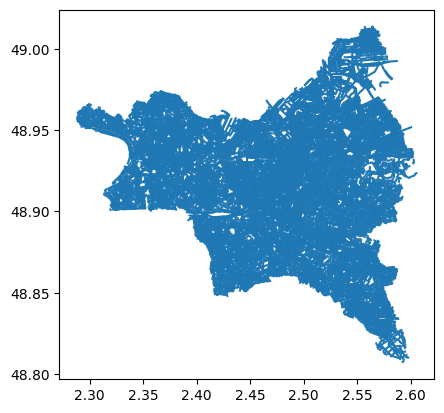

In [191]:
# Takes 10s on my laptop -- loading roads in this case
bdtopo = gpd.read_file("data/BDTOPO/1_DONNEES_LIVRAISON_2024-12-00134/BDT_3-4_GPKG_LAMB93_D093-ED2024-12-15/BDT_3-4_GPKG_LAMB93_D093-ED2024-12-15.gpkg")
print(len(bdtopo),"items")
# Utilisons les memes projections
bdtopo = bdtopo.to_crs(4326)
bdtopo = gpd.sjoin(bdtopo, dpts[dpts.code == "93"], how='left').dropna(subset="code")
print(len(bdtopo),"items")
bdtopo.plot()

## Et on load des batiments du dataset Parcellaire

In [48]:
# Takes 11s on my laptop
pci = gpd.read_file("data/PARCELLAIRE-EXPRESS/1_DONNEES_LIVRAISON_2024-11-00210/PEPCI_1-1_SHP_LAMB93_D093/BATIMENT.SHP")
print(len(pci),"items")
pci = pci.to_crs(4326)
pci = gpd.sjoin(pci, dpts[dpts.code == "93"], how='left').dropna(subset="code")
print(len(pci),"items - sorted")
pci.head(3)

376574 items
376220 items - sorted


,TYPE,geometry,index_right,code,nom
0,Construction légère,"POLYGON ((2.39066 48.90535, 2.3907 48.90536, 2...",93.0,93,Seine-Saint-Denis
1,Bâtiment en dur,"POLYGON ((2.52665 48.87779, 2.52669 48.87777, ...",93.0,93,Seine-Saint-Denis
2,Bâtiment en dur,"POLYGON ((2.52583 48.87706, 2.52582 48.87706, ...",93.0,93,Seine-Saint-Denis


# Prenons une école

In [223]:
pd.DataFrame(annuaire.iloc[0])

,5985
identifiant_de_l_etablissement,0930152K
nom_etablissement,Ecole élémentaire Pierre Lerenard
type_etablissement,Ecole
statut_public_prive,Public
adresse_1,115 rue de l'Avenir
...,...
code_zone_animation_pedagogique,None
libelle_zone_animation_pedagogique,None
code_bassin_formation,None
libelle_bassin_formation,None


In [159]:
# Filtrons autour de d = 100m
d = 0.01 # échelle à retrouver
zone = annuaire.iloc[0].geometry.buffer(d)

#### On coupe ce qu'il y a à l'intérieur de la zone d'intéret

In [245]:
bdtopo_d = bdtopo[bdtopo.geometry.within(zone)].clip(zone)# check with within
pci_d = pci[pci.geometry.within(zone)].clip(zone)# check with within
bdedu_d = bdedu[bdedu.geometry.within(zone)].clip(zone)# check with within
bat_edu_d =  bat_edu[bat_edu.geometry.within(zone)].clip(zone)

C:\Users\JON80843\AppData\Local\Temp\ipykernel_32880\4149730531.py:6: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  bdedu_d.plot(column="toponyme",legend=True, categorical = True, ax = ax, color="black", alpha=0.5)
C:\Users\JON80843\AppData\Local\Temp\ipykernel_32880\4149730531.py:7: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  bat_edu_d.plot(column="toponyme",legend=True, categorical = True, ax = ax, color="yellow")


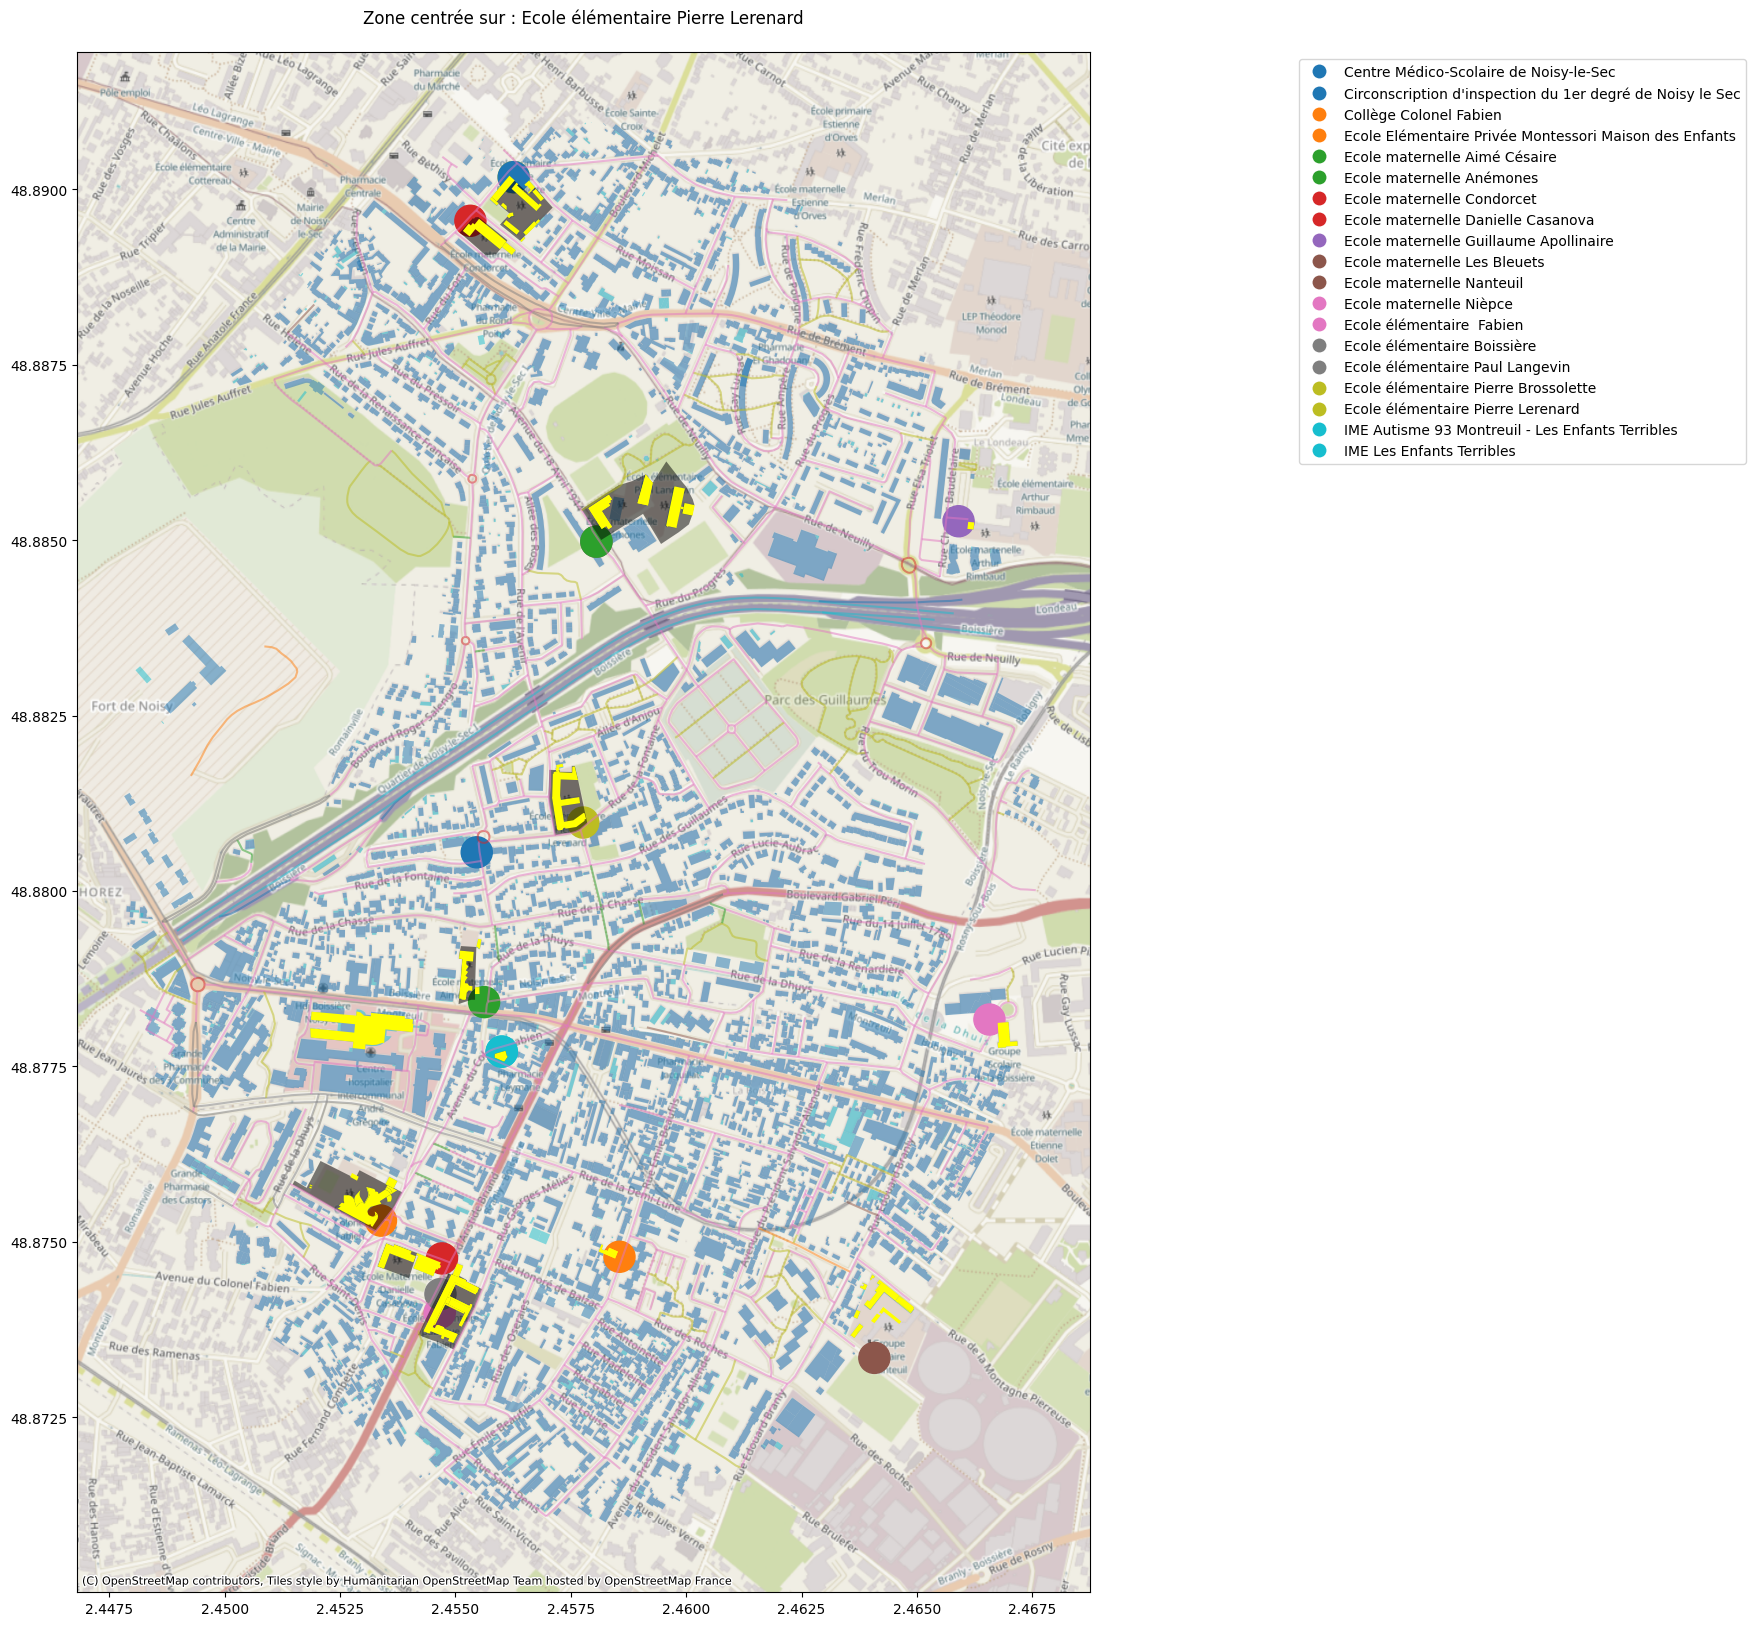

In [255]:
#plots all PCI
fig, ax = plt.subplots(figsize=(20,20))
pci_d.plot(column="TYPE", legend=True, categorical = True, ax = ax, alpha=0.5)
bdtopo_d.plot(column="nature",legend=True, categorical = True, ax = ax, alpha=0.5)
annuaire[annuaire.geometry.within(zone)].clip(zone).plot(column = "nom_etablissement",legend=True, categorical = True, ax = ax, markersize=500, legend_kwds={'loc': 'upper left'})
bdedu_d.plot(column="toponyme",legend=True, categorical = True, ax = ax, color="black", alpha=0.5)
bat_edu_d.plot(column="toponyme",legend=True, categorical = True, ax = ax, color="yellow")
cx.add_basemap(ax, crs=pci_d.crs, zoom=16) # source=cx.providers.OpenStreetMap.Mapnik,
leg = ax.get_legend()
leg.set_bbox_to_anchor((1.2, 0, 0, 1))
ax.set_title("Zone centrée sur : "+annuaire.iloc[0].nom_etablissement+"\n")
plt.show()